# Sector-Adjusted Financial Deterioration Scoring using SEC EDGAR Structured Data

**Research questions**

- **RQ1 — Prediction.** Can a model trained on quarter-T fundamental ratios predict
  which companies' operating-margin trend will fall into the bottom quartile of their
  SIC-sector peers in quarter T+1?
- **RQ2 — Drivers.** Which features carry the signal — flow (change) features or
  stock (level) features — and is the ranking stable across the test window?
- **RQ3 — Usefulness.** Does the model's top-decile watchlist beat naive screening,
  i.e., does an analyst reviewing the highest-scored decile find materially more true
  deteriorations than the base rate?

**Pipeline in one paragraph.** The raw data are the SEC's Financial Statement Data
Sets (DERA): 57 quarterly XBRL archives, 2012 Q1 through 2026 Q1. From 10-K/10-Q
filings, the pipeline builds one row per company per fiscal quarter (355,209 unique rows after
deduplication),
computes six core ratios, a margin-momentum feature (`op_margin_trend`), and six
within-`(quarter, SIC)` sector-percentile features — 13 features total, all known at
quarter T. The label `at_risk` flags companies whose *next*-quarter margin trend
falls at or below the 25th percentile of their sector peer group, yielding 130,338
labeled company-quarters through 2025 Q4. Two untuned scikit-learn baselines
(HistGradientBoosting, RandomForest) are trained on a strictly chronological split
(train < 2022 Q1 ≤ test) and evaluated with PR-AUC and precision@top-10%.

> This notebook **loads saved artifacts only** — it does not re-download EDGAR data,
> rebuild the panel, or retrain models. Every number below comes from a saved
> parquet, CSV, PNG, or joblib file produced by the pipeline scripts.

## 1. Data summary

The full panel (`panel.parquet`) and the labeled modeling set
(`labeled_panel.parquet`) are loaded once here; the labeled set is reused in
section 4 for scoring.

In [1]:
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
from IPython.display import Image, display

ROOT = Path.cwd()
if not (ROOT / "data").exists():          # notebook lives in notebooks/
    ROOT = ROOT.parent

panel_rows = pq.ParquetFile(ROOT / "data/processed/panel.parquet").metadata.num_rows
labeled = pd.read_parquet(ROOT / "data/processed/labeled_panel.parquet")

summary = pd.DataFrame({
    "value": [
        f"{panel_rows:,}",
        f"{len(labeled):,}",
        f"{labeled['fiscal_quarter'].min()} – {labeled['fiscal_quarter'].max()}",
        f"{labeled['cik'].nunique():,}",
        f"{labeled['at_risk'].mean():.4f}",
    ]},
    index=["Full panel rows (company-quarters)", "Labeled rows",
           "Labeled date range", "Unique companies (CIK)",
           "Base rate of at_risk"],
)
summary

,value
Full panel rows (company-quarters),"355,209"
Labeled rows,"130,338"
Labeled date range,2012Q2 – 2025Q4
Unique companies (CIK),"6,677"
Base rate of at_risk,0.2807


**Attrition waterfall** (documented in the README; not recomputed here). Of the
355,209 company-quarter rows in the full panel (unique per `(cik, fiscal_quarter)`
after the README-documented resolution of 745 duplicate pairs), a row enters the labeled set only if
it has a valid `op_margin_trend` at quarter T, a valid margin trend at T+1 (the
label side), a non-null SIC code, and at least 4 labelable companies in its
`(quarter, SIC)` peer group. Before the Q4 flow fix, the labeled set was only
**53,895** rows: the SEC's elimination of Regulation S-K Item 302(a) (effective
early 2021) collapsed quarterly-flow coverage on 10-K filings, destroying Q3/Q4/Q1
labels post-2021. Deriving Q4 flows arithmetically (annual minus Q1–Q3, with no
lookahead) grew the labeled set to **130,338** rows. Rows with any missing feature
are additionally dropped (complete-case) before the chronological split in the
training script.

## 2. RQ1 — Does the model predict deterioration?

Test-set metrics from `outputs/model_metrics.csv`: the naive baseline assigns every
test row a constant probability equal to the training base rate, so its average
precision equals the test positive rate and its expected precision@top-k is the
test base rate. Lift is each model's metric divided by that baseline.

In [2]:
metrics = pd.read_csv(ROOT / "outputs/model_metrics.csv")
m = metrics.set_index(metrics["model"].map({
    "naive_baseline": "Naive baseline",
    "HGB": "HistGradientBoosting",
    "RF": "RandomForest",
}))
metrics_display = pd.DataFrame({
    "PR-AUC": m["pr_auc"].round(4),
    "PR-AUC lift": m["pr_auc_lift"].map(lambda v: f"{v:.2f}x"),
    "Precision @ top 10%": m["precision_at_top10pct"].round(4),
    "Precision@10% lift": m["p10_lift"].map(lambda v: f"{v:.2f}x"),
})
metrics_display.index.name = None
metrics_display

,PR-AUC,PR-AUC lift,Precision @ top 10%,Precision@10% lift
Naive baseline,0.2805,1.00x,0.2805,1.00x
HistGradientBoosting,0.4594,1.64x,0.5450,1.94x
RandomForest,0.4483,1.60x,0.5333,1.90x


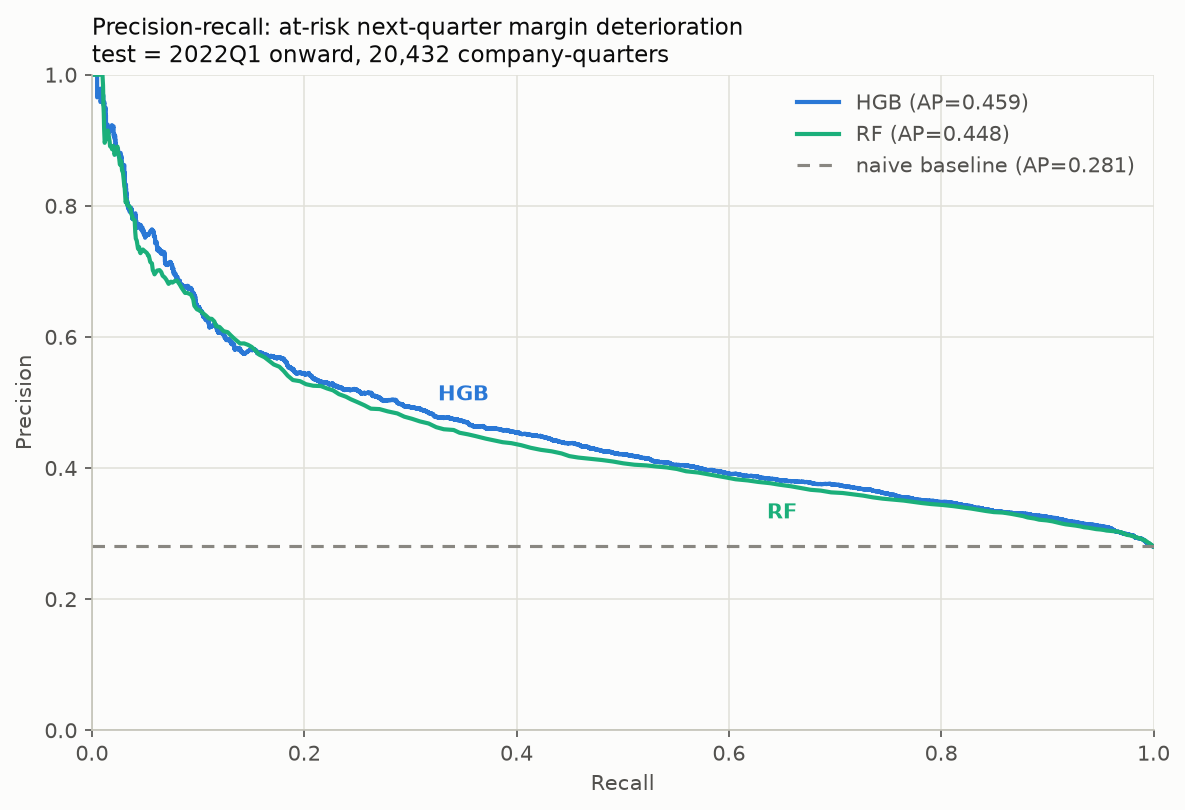

In [3]:
display(Image(filename=str(ROOT / "outputs/pr_curve.png"), width=760))

**Interpretation.** Both models clearly beat naive screening. HistGradientBoosting
reaches a PR-AUC of 0.459 against a naive baseline of 0.281 — a 1.64× lift — and,
more operationally, 54.5% of the companies in its highest-scored test decile
actually deteriorated next quarter, versus 28.1% expected by chance (1.94× lift).
RandomForest lands just behind on both metrics, which suggests the signal is a
property of the features rather than of one particular learner. (All HGB numbers
come from the seeded `random_state=42` model saved to disk — the same model that
scores the watchlist in section 4.) The precision–recall curves sit well above the
baseline across the full recall range, so the advantage is not confined to a few
easy cases at the extreme top of the ranking.

## 3. RQ2 — Which features drive the predictions?

Permutation importance (scoring = average precision, 5 repeats, seed 42) on the
full test set, from `outputs/permutation_importance.csv` — HistGradientBoosting and
RandomForest side by side.

In [4]:
perm = pd.read_csv(ROOT / "outputs/permutation_importance.csv", index_col="feature")
perm_display = perm.sort_values("hgb_importance", ascending=False).round(5)
perm_display.columns = ["HGB importance", "HGB rank", "RF importance", "RF rank"]
perm_display

,HGB importance,HGB rank,RF importance,RF rank
feature,,,,
op_margin_trend,0.11501,1,0.08773,1
operating_margin,0.03621,2,0.03904,2
operating_margin_sector_pctile,0.02832,3,0.02616,3
revenue_growth_sector_pctile,0.01619,4,0.01318,5
revenue_growth,0.00922,5,0.01361,4
roe,0.00755,6,0.01021,6
cash_to_assets_sector_pctile,0.00594,7,0.00551,10
roe_sector_pctile,0.00477,8,0.00784,7
current_ratio,0.00455,9,0.00700,8


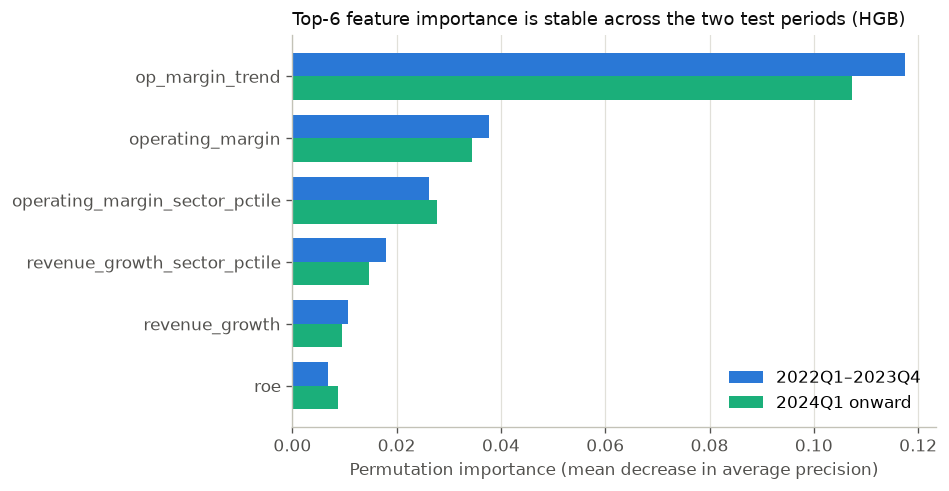

In [5]:
by_period = pd.read_csv(ROOT / "outputs/importance_by_period.csv", index_col="feature")
top6 = by_period.sort_values("importance_2022_2023", ascending=False).head(6)[::-1]

fig, ax = plt.subplots(figsize=(8, 4.2), dpi=120)
y = np.arange(len(top6))
h = 0.38
ax.barh(y + h / 2, top6["importance_2022_2023"], height=h,
        color="#2a78d6", label="2022Q1–2023Q4")
ax.barh(y - h / 2, top6["importance_2024_on"], height=h,
        color="#1baf7a", label="2024Q1 onward")
ax.set_yticks(y, top6.index)
ax.set_xlabel("Permutation importance (mean decrease in average precision)",
              color="#52514e")
ax.set_title("Top-6 feature importance is stable across the two test periods (HGB)",
             loc="left", fontsize=11, color="#0b0b0b")
ax.grid(True, axis="x", color="#e1e0d9", linewidth=0.75)
ax.set_axisbelow(True)
for s in ["top", "right"]:
    ax.spines[s].set_visible(False)
for s in ["left", "bottom"]:
    ax.spines[s].set_color("#c3c2b7")
ax.tick_params(colors="#52514e")
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

In [6]:
corr = pd.read_csv(ROOT / "outputs/feature_correlation.csv", index_col=0)
flagged = [
    {"feature_a": a, "feature_b": b, "correlation": round(corr.loc[a, b], 3)}
    for i, a in enumerate(corr.columns)
    for b in corr.columns[i + 1:]
    if abs(corr.loc[a, b]) > 0.7
]
pd.DataFrame(flagged)

,feature_a,feature_b,correlation
0,liabilities_to_assets,liabilities_to_assets_sector_pctile,0.755
1,operating_margin_sector_pctile,roe_sector_pctile,0.721


**Interpretation.** The ranking shows a clear **flow-over-stock** pattern.
`op_margin_trend` — the quarter-over-quarter *change* in operating margin —
dominates at roughly 3× the importance of the next feature, which is consistent
with the label being the sector-relative quartile of that same quantity one quarter
ahead: margin momentum carries over. The next tier is the margin level and its
sector percentile, followed by revenue growth (another flow). Stock/level features
— leverage, current ratio, cash — contribute least, and both models agree on the
top-6 ordering. That top-6 ranking is also **temporally stable**: recomputing
importance separately on the two halves of the test window (2022Q1–2023Q4 vs
2024Q1 onward) preserves the order exactly, so the model is not riding a regime
peculiar to one sub-period. Multicollinearity is mild — only two pairs exceed
|r| = 0.7 (each a raw ratio or percentile against a closely related percentile) —
which tree ensembles tolerate, though it means importance is shared within those
pairs rather than concentrated.

## 4. RQ3 — Does the watchlist beat naive screening?

Here the saved (seeded) HistGradientBoosting model scores the test portion of the
labeled panel — the same complete-feature, chronological test set the training
script used (rows with `fiscal_quarter` ≥ 2022Q1). The table shows what an analyst
would actually see: the highest-risk names from the top decile of scores, alongside
whether each company in fact deteriorated the following quarter.

In [7]:
FEATURES = [
    "operating_margin", "current_ratio", "liabilities_to_assets",
    "revenue_growth", "roe", "cash_to_assets", "op_margin_trend",
    "operating_margin_sector_pctile", "current_ratio_sector_pctile",
    "liabilities_to_assets_sector_pctile", "revenue_growth_sector_pctile",
    "roe_sector_pctile", "cash_to_assets_sector_pctile",
]
hgb = joblib.load(ROOT / "data/models/hgb_baseline.joblib")

complete = labeled.dropna(subset=FEATURES + ["at_risk"])
test = complete[complete["fiscal_quarter"].astype(str) >= "2022Q1"].copy()
test["risk_score"] = hgb.predict_proba(test[FEATURES])[:, 1]

k = int(np.ceil(0.10 * len(test)))
top_decile = test.nlargest(k, "risk_score")
print(f"test rows: {len(test):,}   top decile: {k:,} rows   "
      f"precision in top decile: {top_decile['at_risk'].mean():.4f}")

watchlist = top_decile.nlargest(18, "risk_score")[
    ["name", "sic", "fiscal_quarter", "risk_score", "at_risk"]
]
watchlist = watchlist.assign(sic=watchlist["sic"].astype(int),
                             risk_score=watchlist["risk_score"].round(3))
watchlist.columns = ["Company", "SIC", "Quarter", "Risk score", "Deteriorated (at_risk)"]
watchlist.reset_index(drop=True)

test rows: 20,432   top decile: 2,044 rows   precision in top decile: 0.5450


,Company,SIC,Quarter,Risk score,Deteriorated (at_risk)
0,SCYNEXIS INC,2834,2023Q2,0.929,1
1,ADAPTIMMUNE THERAPEUTICS PLC,2836,2024Q2,0.926,1
2,NEUROONE MEDICAL TECHNOLOGIES CORP,3841,2024Q4,0.925,1
3,"ACUTUS MEDICAL, INC.",3841,2022Q4,0.920,1
4,"POSEIDA THERAPEUTICS, INC.",2836,2022Q3,0.916,1
5,"ARS PHARMACEUTICALS, INC.",2834,2024Q4,0.915,1
6,MACROGENICS INC,2834,2024Q3,0.913,1
7,MOTORSPORT GAMES INC.,7372,2024Q2,0.910,1
8,THREDUP INC.,5961,2024Q4,0.909,1
9,"TG THERAPEUTICS, INC.",2834,2023Q3,0.907,1


**Interpretation.** This is the concrete form of the precision@top-10% number from
section 2. The test window contains 20,432 company-quarters; the top decile by
model score is 2,044 of them, and 54.5% of those flagged rows genuinely fell into
their sector's bottom quartile of margin deterioration the next quarter — the same
0.545 as the section-2 table, versus the 28% an analyst would hit by screening the
same number of names at random (or by any constant rule). In other words, a
screener working exclusively
from this watchlist roughly **doubles the hit rate** of naive screening, before any
model tuning. The highest-scored names carry scores well above 0.9, and the
handful of false positives visible even at the very top of the list is a useful
reminder that this is a triage tool for prioritizing analyst attention, not a
verdict on any individual company.

## 5. Limitations

As documented in the README's methodology notes:

- **Revenue/margin coverage constrains the sample.** An operating margin is
  computable on only 49.2% of panel rows, and the label needs a three-quarter chain
  of margins plus a ≥4-firm peer group, so only ~37% of panel rows (130,338 of
  355,209) are labelable — with post-2021 Q4 coverage depending on the arithmetic
  Q4-flow derivation after the SEC dropped Item 302(a). The narrow debt ratio was
  excluded from the feature set for the same reason (58.77% coverage in the
  labeled set).
- **Survivorship / exit bias.** A row is labeled only if the company files a
  comparable quarter T+1. Firms that delist, are acquired, or go bankrupt exit the
  panel at exactly the moment of greatest deterioration, so the worst outcomes are
  under-represented in both training and evaluation.
- **SIC coarseness.** Peer groups are raw SIC codes, recomputed each quarter. SIC is
  a dated classification with uneven granularity; peer groups with fewer than 4
  labelable companies are dropped, and misclassified companies get mismatched peers.
- **Scope: operating companies only.** The ratios presuppose an operating business
  with meaningful revenues and operating margin. Financial firms, funds, shells, and
  pre-revenue companies have undefined or non-meaningful ratios (`safe_ratio`
  returns NaN for non-positive denominators) and fall out of the complete-case
  sample; results should not be extrapolated to them.